# 🌲 Crop Recommendation — Algorithm 2: Random Forest

**Dataset:** Crop Recommendation Dataset  
**Source:** https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset  
**Type:** Supervised Learning — Multi-class Classification  
**Algorithm:** Random Forest Classifier  

---

In [1]:
# ── CELL 1 — Import Libraries ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


In [2]:
# ── CELL 2 — Load Dataset ──────────────────────────────────────────────────
df = pd.read_csv('/content/Crop_recommendation.csv')
print(f'✅ Dataset loaded!')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

✅ Dataset loaded!
Shape: 2200 rows × 8 columns


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
# ── CELL 3 — Prepare Features & Target ────────────────────────────────────
X = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
y = df['label']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f'Features shape : {X.shape}')
print(f'Target classes : {len(le.classes_)}')
print(f'Classes        : {list(le.classes_)}')

Features shape : (2200, 7)
Target classes : 22
Classes        : ['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']


In [4]:
# ── CELL 4 — Train / Test Split ────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f'Training set : {X_train.shape[0]} samples')
print(f'Test set     : {X_test.shape[0]} samples')
print(f'Split ratio  : 80% train / 20% test')

Training set : 1760 samples
Test set     : 440 samples
Split ratio  : 80% train / 20% test


In [5]:
# ── CELL 5 — Train Default Random Forest ──────────────────────────────────
rf_default = RandomForestClassifier(random_state=42)
rf_default.fit(X_train, y_train)

default_acc = accuracy_score(y_test, rf_default.predict(X_test))
print('✅ Default Random Forest trained!')
print(f'Default Test Accuracy : {default_acc:.4f} ({default_acc*100:.2f}%)')
print(f'Number of trees       : {rf_default.n_estimators}')

✅ Default Random Forest trained!
Default Test Accuracy : 0.9955 (99.55%)
Number of trees       : 100


In [6]:
# ── CELL 6 — Hyperparameter Tuning with GridSearchCV ──────────────────────
param_grid = {
    'n_estimators'     : [50, 100, 200],
    'max_depth'        : [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf' : [1, 2],
    'max_features'     : ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f'\n✅ Best Parameters  : {grid_search.best_params_}')
print(f'Best CV Accuracy    : {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 72 candidates, totalling 360 fits

✅ Best Parameters  : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best CV Accuracy    : 0.9960


In [8]:
# ── CELL 7 — Best Model ───────────────────────────────────────────────────
best_rf = grid_search.best_estimator_

print('✅ Best Random Forest model ready!')
print(f'Number of trees : {best_rf.n_estimators}')
print(f'Max depth       : {best_rf.max_depth}')
print(f'Max features    : {best_rf.max_features}')

✅ Best Random Forest model ready!
Number of trees : 100
Max depth       : 10
Max features    : sqrt


In [9]:
# ── CELL 8 — Predictions ──────────────────────────────────────────────────
y_pred       = best_rf.predict(X_test)
y_pred_proba = best_rf.predict_proba(X_test)

print('✅ Predictions generated!')
print(f'Sample predictions (encoded) : {y_pred[:10]}')
print(f'Sample predictions (labels)  : {list(le.inverse_transform(y_pred[:10]))}')

✅ Predictions generated!
Sample predictions (encoded) : [16  1  6 11 16  3 20  2  1 16]
Sample predictions (labels)  : ['orange', 'banana', 'cotton', 'maize', 'orange', 'chickpea', 'rice', 'blackgram', 'banana', 'orange']


In [10]:
# ── CELL 9 — Cross Validation ─────────────────────────────────────────────
cv_scores = cross_val_score(best_rf, X, y_encoded, cv=10, scoring='accuracy')

print('=== 10-Fold Cross Validation ===')
print(f'Scores  : {np.round(cv_scores, 4)}')
print(f'Mean    : {cv_scores.mean():.4f}')
print(f'Std Dev : {cv_scores.std():.4f}')

=== 10-Fold Cross Validation ===
Scores  : [1.     0.9955 1.     0.9909 0.9955 0.9955 0.9955 0.9955 0.9773 0.9955]
Mean    : 0.9941
Std Dev : 0.0061


In [11]:
# ── CELL 10 — Evaluation Metrics ──────────────────────────────────────────
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
f1        = f1_score(y_test, y_pred, average='weighted')
roc_auc   = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')

print('=' * 45)
print('     RANDOM FOREST — EVALUATION METRICS')
print('=' * 45)
print(f'  Accuracy          : {accuracy:.4f}  ({accuracy*100:.2f}%)')
print(f'  Precision (wtd)   : {precision:.4f}')
print(f'  Recall (wtd)      : {recall:.4f}')
print(f'  F1 Score (wtd)    : {f1:.4f}')
print(f'  ROC-AUC (ovr)     : {roc_auc:.4f}')
print(f'  CV Mean Accuracy  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print('=' * 45)

     RANDOM FOREST — EVALUATION METRICS
  Accuracy          : 0.9955  (99.55%)
  Precision (wtd)   : 0.9957
  Recall (wtd)      : 0.9955
  F1 Score (wtd)    : 0.9955
  ROC-AUC (ovr)     : 1.0000
  CV Mean Accuracy  : 0.9941 ± 0.0061


In [12]:
# ── CELL 11 — Classification Report ──────────────────────────────────────
print('=== Full Classification Report ===')
print(classification_report(y_test, y_pred, target_names=le.classes_))

=== Full Classification Report ===
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00   

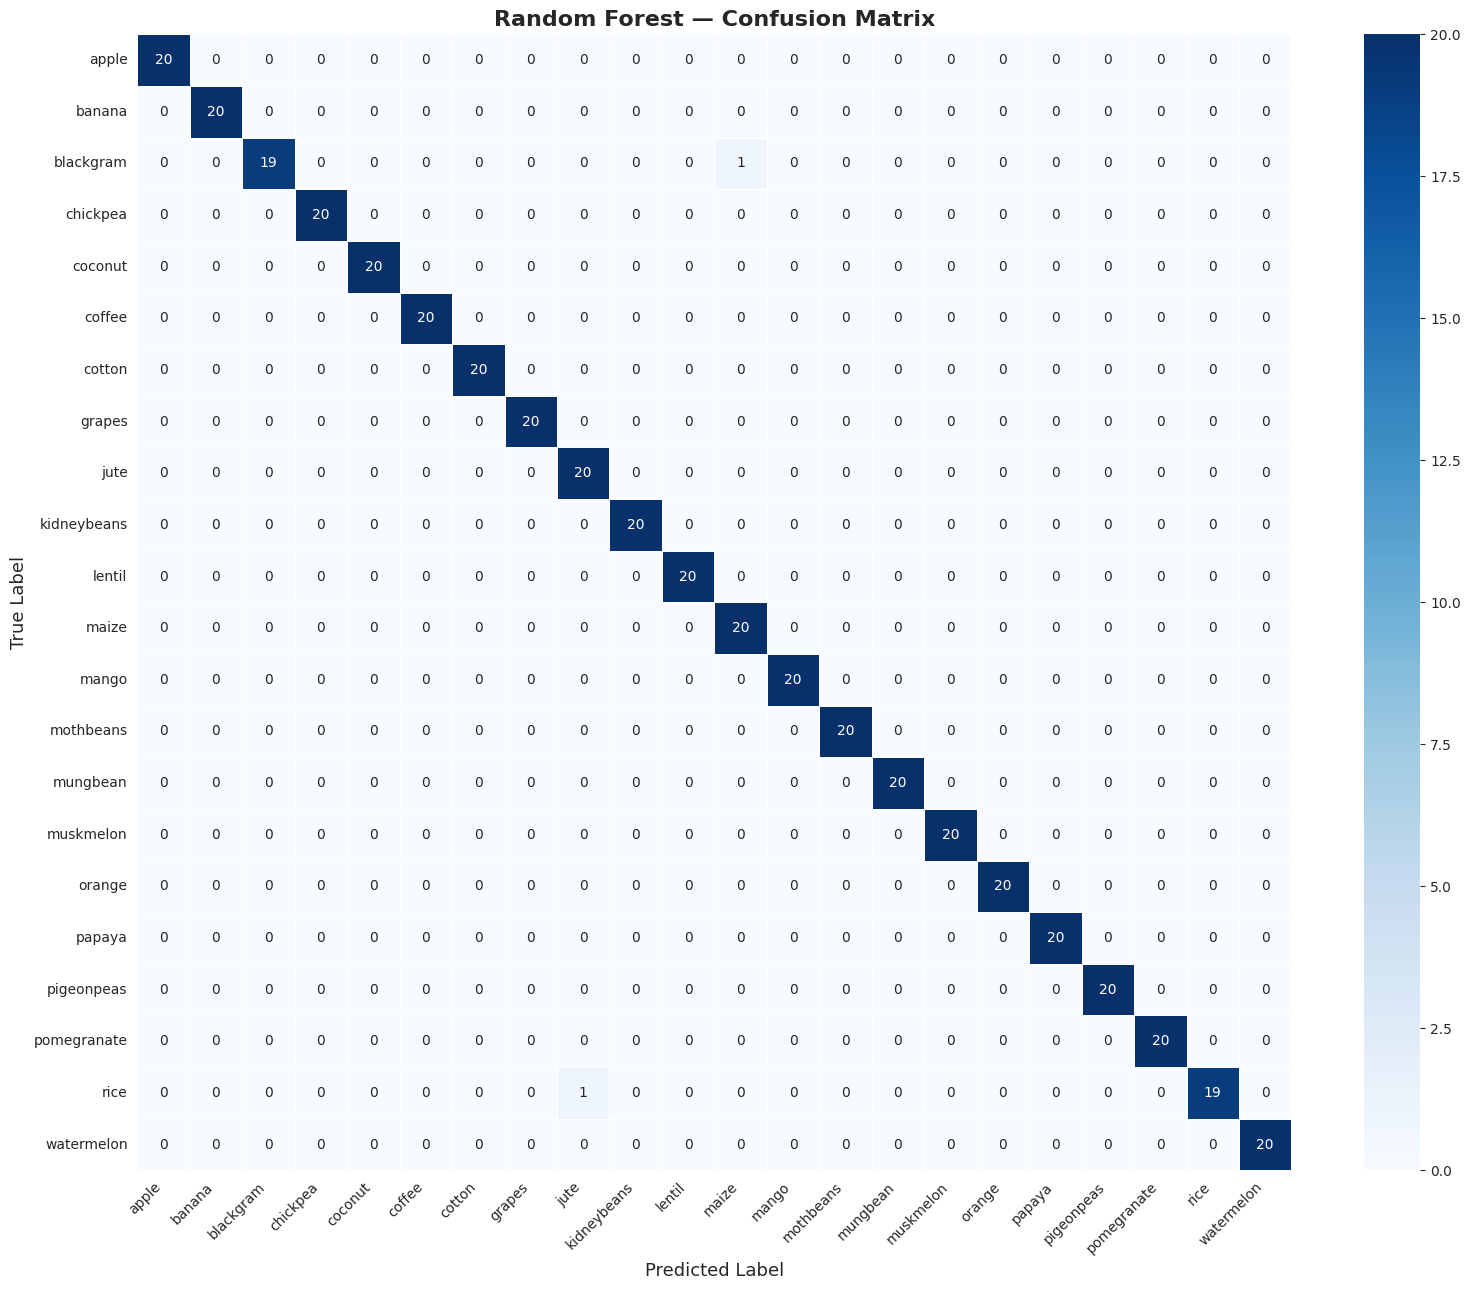

In [13]:
# ── CELL 12 — Confusion Matrix ────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(16, 13))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5)
plt.title('Random Forest — Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=13)
plt.ylabel('True Label', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

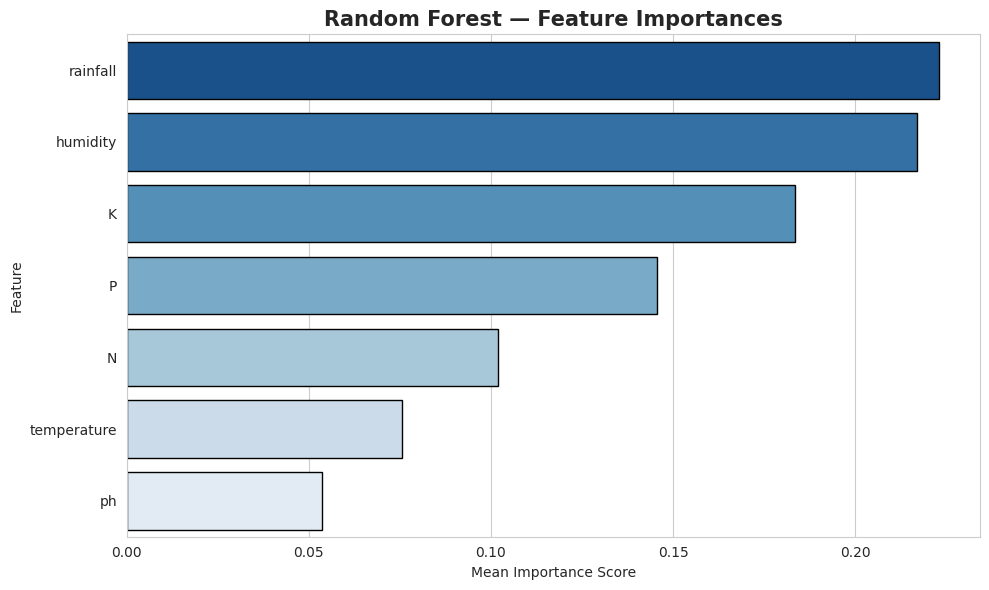

    Feature  Importance      Std
   rainfall    0.223133 0.063733
   humidity    0.216879 0.052111
          K    0.183446 0.063338
          P    0.145579 0.052250
          N    0.101962 0.037665
temperature    0.075522 0.033211
         ph    0.053479 0.028190


In [14]:
# ── CELL 13 — Feature Importances ────────────────────────────────────────
feature_names = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
importances   = best_rf.feature_importances_
std           = np.std([tree.feature_importances_ for tree in best_rf.estimators_], axis=0)

feat_imp_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': importances,
    'Std'       : std
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature',
            palette='Blues_r', edgecolor='black')
plt.title('Random Forest — Feature Importances', fontsize=15, fontweight='bold')
plt.xlabel('Mean Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print(feat_imp_df.to_string(index=False))

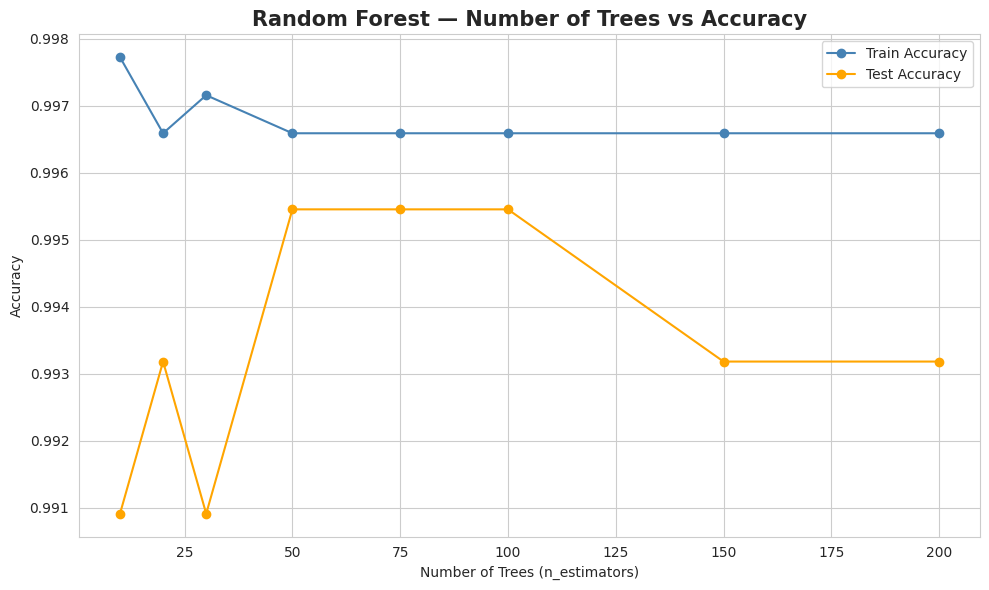

In [15]:
# ── CELL 14 — n_estimators vs Accuracy ───────────────────────────────────
# Shows how accuracy changes as we add more trees
n_estimator_range = [10, 20, 30, 50, 75, 100, 150, 200]
train_accs, test_accs = [], []

for n in n_estimator_range:
    rf_tmp = RandomForestClassifier(n_estimators=n, random_state=42,
                                     **{k: v for k, v in grid_search.best_params_.items()
                                        if k != 'n_estimators'})
    rf_tmp.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, rf_tmp.predict(X_train)))
    test_accs.append(accuracy_score(y_test,  rf_tmp.predict(X_test)))

plt.figure(figsize=(10, 6))
plt.plot(n_estimator_range, train_accs, 'o-', color='steelblue', label='Train Accuracy')
plt.plot(n_estimator_range, test_accs,  'o-', color='orange',    label='Test Accuracy')
plt.title('Random Forest — Number of Trees vs Accuracy', fontsize=15, fontweight='bold')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

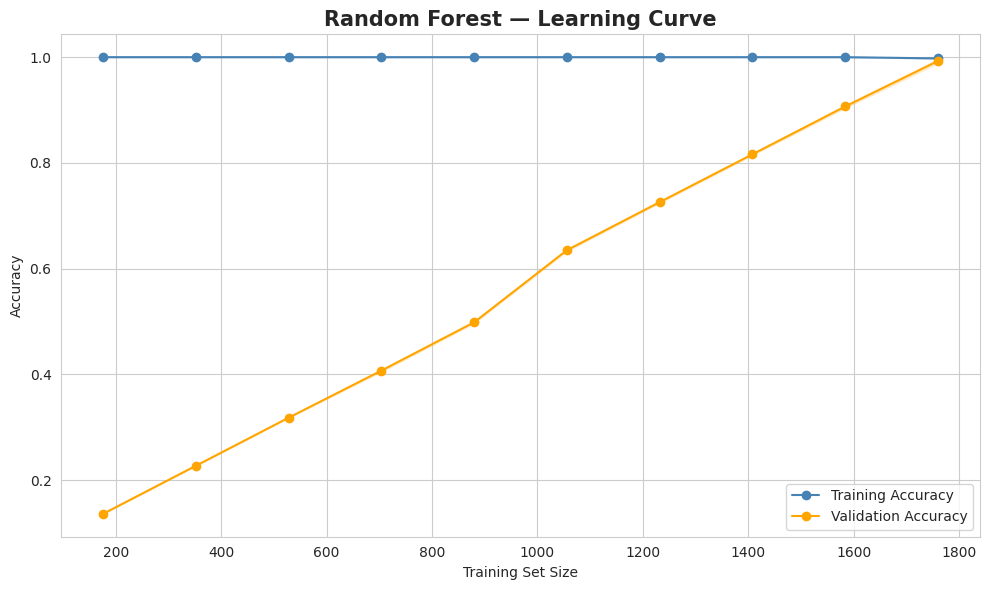

In [16]:
# ── CELL 15 — Learning Curve ──────────────────────────────────────────────
train_sizes, train_scores, val_scores = learning_curve(
    best_rf, X, y_encoded,
    cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Training Accuracy')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='steelblue')
plt.plot(train_sizes, val_mean, 'o-', color='orange', label='Validation Accuracy')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='orange')
plt.title('Random Forest — Learning Curve', fontsize=15, fontweight='bold')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# ── CELL 16 — Metrics Summary (Save for Report Comparison) ───────────────
metrics_rf = {
    'Algorithm' : 'Random Forest',
    'Accuracy'  : round(accuracy, 4),
    'Precision' : round(precision, 4),
    'Recall'    : round(recall, 4),
    'F1 Score'  : round(f1, 4),
    'ROC-AUC'   : round(roc_auc, 4),
    'CV Mean'   : round(cv_scores.mean(), 4),
    'CV Std'    : round(cv_scores.std(), 4)
}

metrics_df = pd.DataFrame([metrics_rf])
print('=== Metrics Summary (copy this to your comparison notebook) ===')
print(metrics_df.to_string(index=False))

metrics_df.to_csv('metrics_random_forest.csv', index=False)
print('\n✅ Metrics saved to metrics_random_forest.csv')

=== Metrics Summary (copy this to your comparison notebook) ===
    Algorithm  Accuracy  Precision  Recall  F1 Score  ROC-AUC  CV Mean  CV Std
Random Forest    0.9955     0.9957  0.9955    0.9955      1.0   0.9941  0.0061

✅ Metrics saved to metrics_random_forest.csv


---
## ✅ Algorithm 2 Complete!

| Metric | Value |
|--------|-------|
| Accuracy | See Cell 10 |
| Precision | See Cell 10 |
| Recall | See Cell 10 |
| F1 Score | See Cell 10 |
| ROC-AUC | See Cell 10 |

**Next:** Open `04_KNN_Colab.ipynb` for Algorithm 3 🔵